# 改良したp-GCMCの実行ファイル

Henry constant (single): 0.03203406767222591
Henry constant (dual): 0.7447536088647919


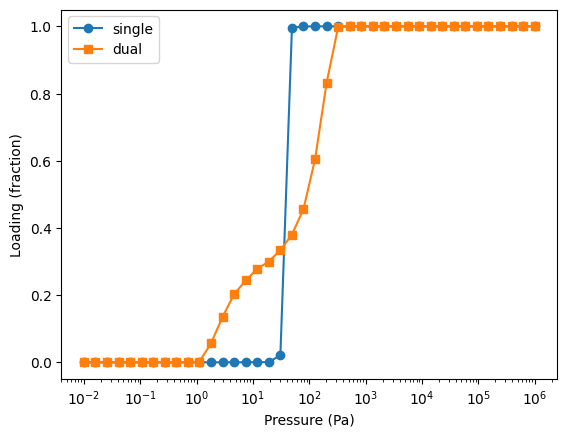

In [ ]:
### --- import block --- ###
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from c01_isotherm_simulation import IsothermSimulator
from c01_compute_henry_constant import compute_henry_constant


# ==========================================================
# Main Execution
# ==========================================================

if __name__ == "__main__":

    T = 298.0

    # サンプリング圧力は対数で与える
    pressures = np.logspace(-2, 6, 40)  # 10^2 – 10^6 Pa(10 bar)

    single_params = {
        "mode": "single",
        "sites": {
            "only": {
                "energy_mu": -20000.0,
                "energy_sigma": 0.0
            }
        }
    }

    dual_params = {
        "mode": "dual",
        "sites_distribution": {
            "strong": 0.3,
            "weak": 0.7,
        },
        "sites": {
            "strong": {
                "energy_mu": -30000.0,
                "energy_sigma": 2000.0,
            },
            "weak": {
                "energy_mu": -15000.0,
                "energy_sigma": 2000.0,
            }
        }
    }

    # Isotherm Simulation
    # simlator = IsothermSimulator() #　callableにしたいが、今は措く
    iso_single, energies_single = IsothermSimulator.run_isotherm(single_params, T, pressures)
    iso_dual, energies_dual = IsothermSimulator.run_isotherm(dual_params, T, pressures)

    # Henry constant
    KH_single = compute_henry_constant(energies_single, T, P0=1e5)
    KH_dual = compute_henry_constant(energies_dual, T, P0=1e5)

    print("Henry constant (single):", KH_single)
    print("Henry constant (dual):", KH_dual)


    # # save result
    # results = {
    #     ""
    # }

    # result plot
    plt.figure()
    plt.semilogx(pressures, iso_single, marker='o', label="single")
    plt.semilogx(pressures, iso_dual, marker='s', label="dual")
    plt.xlabel("Pressure (Pa)")
    plt.ylabel("Loading (fraction)")
    plt.legend()
    plt.show()



## データ保存

In [ ]:
import pandas as pd

df_isotherm_single = pd.DataFrame(
    {
    "pressure": pressures,
    "theta": iso_single
    },
).astype(float)

display(df_isotherm_single.head())

single_save_to = r"C:\Users\y_7up\Documents\projects\mi_dev\04_mof\output\gcmc\isotherm_single.csv"

df_isotherm_single.to_csv(single_save_to, encoding="utf-8", index=False)

df_isotherm_dual = pd.DataFrame(
    {
    "pressure": pressures,
    "theta": iso_dual,
    },
).astype(float)

dual_save_to = r"C:\Users\y_7up\Documents\projects\mi_dev\04_mof\output\gcmc\isotherm_dual.csv"

df_isotherm_dual.to_csv(dual_save_to, encoding="utf-8", index=False)

